Należy przeprowadzić analizę regresji dla poniższych danych: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset Stwórzmy model regresji dla zmiennej zależnej density w zależności od pozostałych zmiennych (o watościach ciągłych)

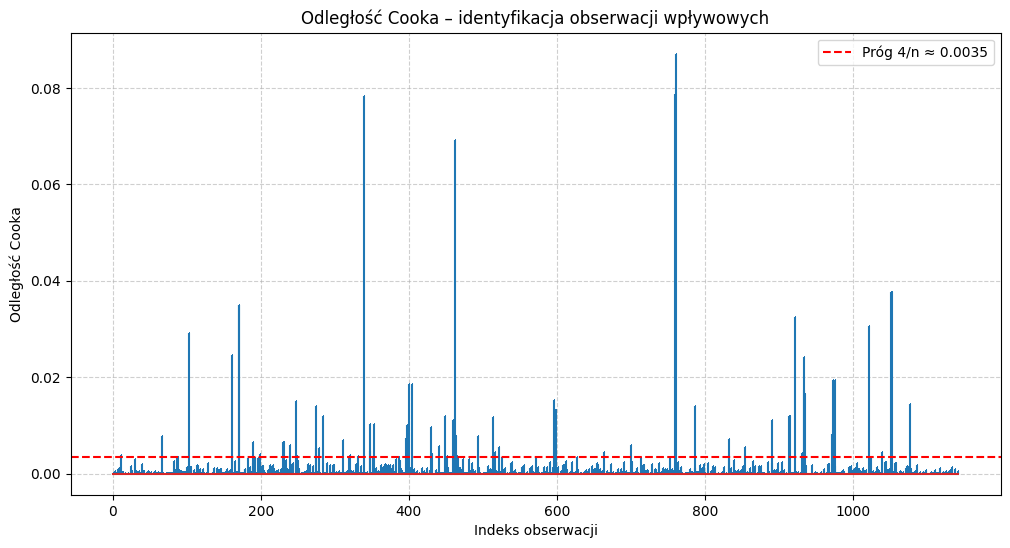

Liczba obserwacji przekraczających próg 4/n: 72


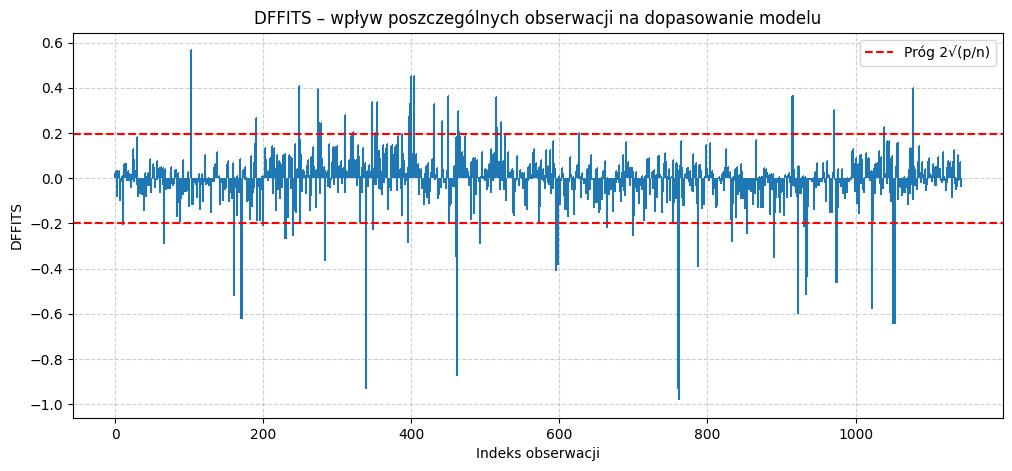

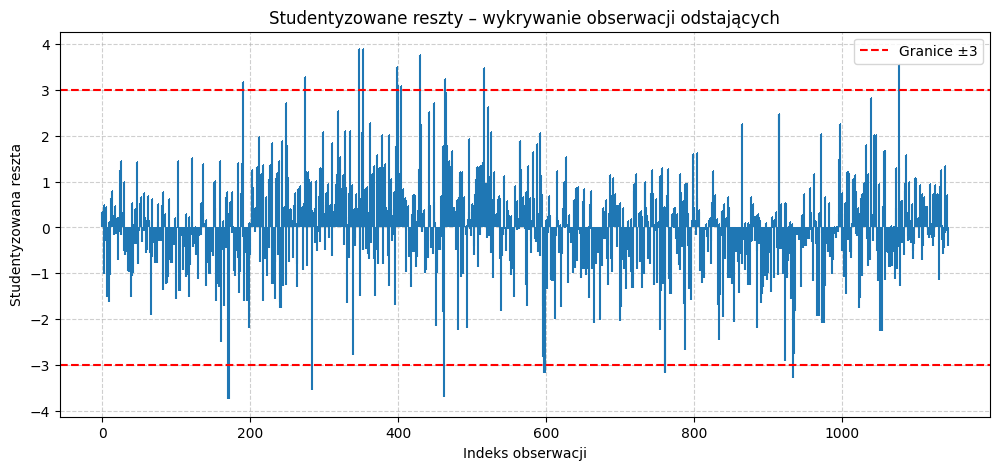

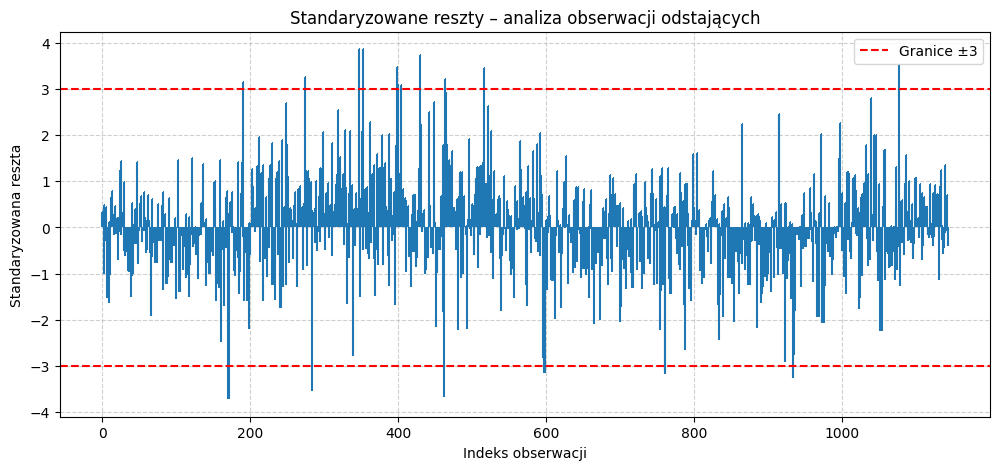

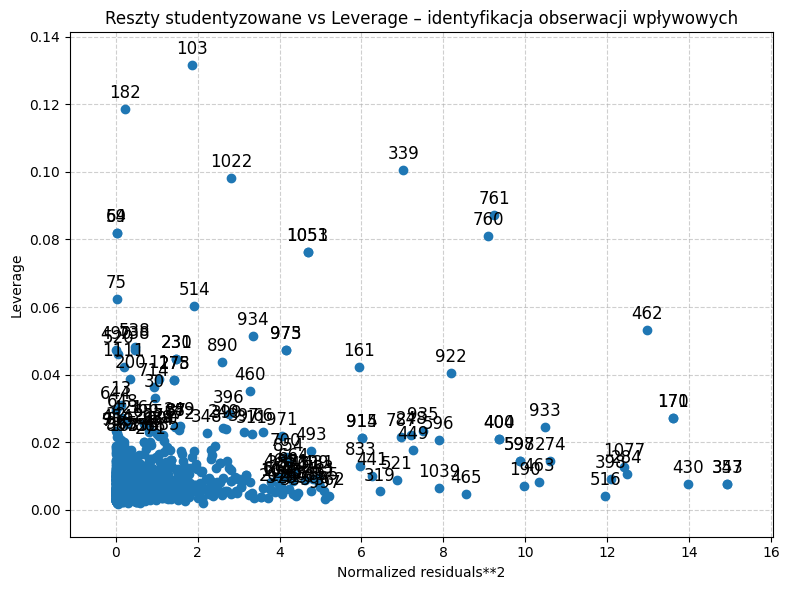

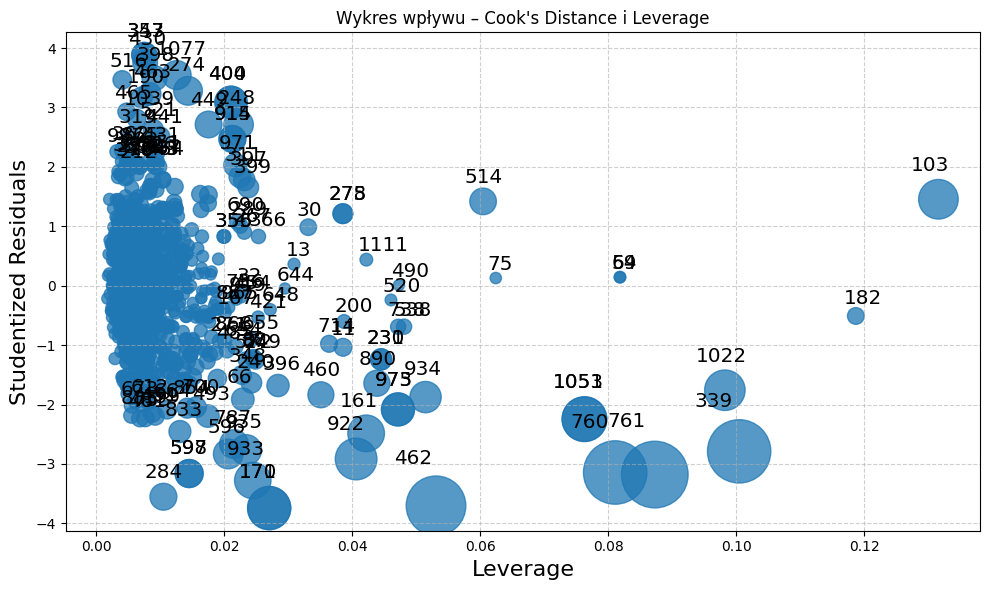

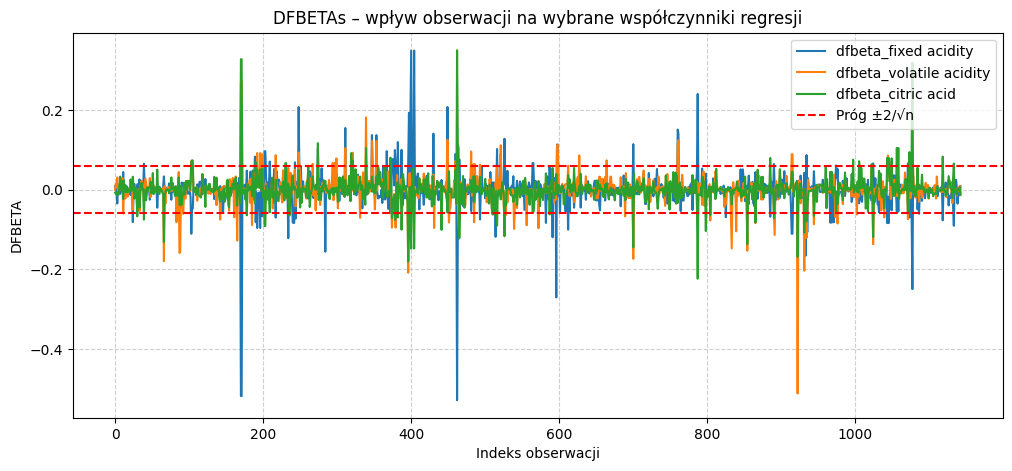

      cooks_distance    dffits  studentized_residual  standardized_residual  \
0           0.000051  0.023572              0.333112               0.333243   
1           0.000093  0.032011              0.356465               0.356602   
2           0.000082  0.030023              0.485039               0.485203   
3           0.000621 -0.082670             -1.003566              -1.003563   
4           0.000051  0.023572              0.333112               0.333243   
...              ...       ...                   ...                    ...   
1138        0.000920  0.100627              1.349453               1.348964   
1139        0.000010 -0.010248             -0.111744              -0.111793   
1140        0.000004 -0.006888             -0.087078              -0.087116   
1141        0.000476  0.072326              0.708056               0.708212   
1142        0.000132 -0.038050             -0.404547              -0.404696   

      leverage  dfbeta_const  dfbeta_fixed acidity 

In [4]:
from statsmodels.graphics.regressionplots import plot_leverage_resid2, influence_plot
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy.stats import zscore
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

wine_data = pd.read_csv("WineQT.csv")

predictors = wine_data.drop(columns=["density", "quality", "Id"])
target = wine_data["density"]

predictors_const = sm.add_constant(predictors)

regression_model = sm.OLS(target, predictors_const).fit()

influence_measures = regression_model.get_influence()
cooks_distances = influence_measures.cooks_distance[0]

n_observations = len(wine_data)
cooks_threshold = 4 / n_observations

plt.figure(figsize=(12, 6))
plt.stem(np.arange(len(cooks_distances)), cooks_distances, markerfmt=",")
plt.axhline(y=cooks_threshold, color='red', linestyle='--', label=f'Próg 4/n ≈ {cooks_threshold:.4f}')
plt.title("Odległość Cooka – identyfikacja obserwacji wpływowych")
plt.xlabel("Indeks obserwacji")
plt.ylabel("Odległość Cooka")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print("Liczba obserwacji przekraczających próg 4/n:", np.sum(cooks_distances > cooks_threshold))

wine_data["cooks_distance"] = cooks_distances
wine_data["dffits"] = influence_measures.dffits[0]
wine_data["studentized_residual"] = influence_measures.resid_studentized_external
wine_data["standardized_residual"] = influence_measures.resid_studentized_internal
wine_data["leverage"] = influence_measures.hat_matrix_diag

dfbetas_matrix = influence_measures.dfbetas
dfbetas_df = pd.DataFrame(dfbetas_matrix, columns=[f"dfbeta_{var}" for var in regression_model.params.index])
wine_data = pd.concat([wine_data, dfbetas_df], axis=1)

plt.figure(figsize=(12, 5))
plt.stem(np.arange(len(wine_data)), wine_data["dffits"], markerfmt=",", basefmt=" ")
dffits_threshold = 2 * np.sqrt(len(regression_model.params) / n_observations)
plt.axhline(y=dffits_threshold, color='r', linestyle='--', label="Próg 2√(p/n)")
plt.axhline(y=-dffits_threshold, color='r', linestyle='--')
plt.title("DFFITS – wpływ poszczególnych obserwacji na dopasowanie modelu")
plt.xlabel("Indeks obserwacji")
plt.ylabel("DFFITS")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(12, 5))
plt.stem(np.arange(len(wine_data)), wine_data["studentized_residual"], markerfmt=",", basefmt=" ")
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--', label='Granice ±3')
plt.title("Studentyzowane reszty – wykrywanie obserwacji odstających")
plt.xlabel("Indeks obserwacji")
plt.ylabel("Studentyzowana reszta")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(12, 5))
plt.stem(np.arange(len(wine_data)), wine_data["standardized_residual"], markerfmt=",", basefmt=" ")
plt.axhline(y=3, color='r', linestyle='--')
plt.axhline(y=-3, color='r', linestyle='--', label='Granice ±3')
plt.title("Standaryzowane reszty – analiza obserwacji odstających")
plt.xlabel("Indeks obserwacji")
plt.ylabel("Standaryzowana reszta")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
plot_leverage_resid2(regression_model, ax=ax)
plt.title("Reszty studentyzowane vs Leverage – identyfikacja obserwacji wpływowych")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
influence_plot(regression_model, ax=ax, criterion="cooks")
plt.title("Wykres wpływu – Cook's Distance i Leverage")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

dfbetas_df.iloc[:, 1:4].plot(kind="line", figsize=(12, 5))
dfbeta_threshold = 2 / np.sqrt(n_observations)
plt.axhline(y=dfbeta_threshold, color="red", linestyle="--", label="Próg ±2/√n")
plt.axhline(y=-dfbeta_threshold, color="red", linestyle="--")
plt.title("DFBETAs – wpływ obserwacji na wybrane współczynniki regresji")
plt.ylabel("DFBETA")
plt.xlabel("Indeks obserwacji")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

influence_summary = wine_data[[
    "cooks_distance", "dffits", "studentized_residual", "standardized_residual", "leverage"
] + list(dfbetas_df.columns)]

print(influence_summary)